# BraTS 2020 — 2D U-Net Baseline

**모델**: 표준 2D U-Net (Encoder-Decoder + Skip Connection)  
**입력**: `(B, 4, H, W)` — axial slice 1장 × 4 modality  
**출력**: `(B, 3, H, W)` — WT / TC / ET 이진 마스크

---

### 2D U-Net 전처리 설계 근거

| 항목 | 결정 | 이유 |
|------|------|------|
| 입력 단위 | axial slice 1장 | 2D baseline, 앞뒤 맥락 없음 |
| 정규화 | Z-score (뇌 내부 기준) | 배경 voxel 통계 왜곡 방지 |
| Crop | bounding box → 192×192 | 배경 제거 + 고정 크기 |
| 빈 slice 제거 | brain voxel < 500 | 무의미한 배경 slice 제거 |
| 클래스 불균형 | tumor slice 70% 오버샘플 | 빈 slice가 전체의 ~57% |
| 과적합 방지 | Dropout + 증강 + early stopping | slice 단위라 패턴 반복 위험 |
| Normalization | GroupNorm (BatchNorm 대체) | MacOS MPS backward 버그 방지 |

## 0. 패키지 설치

In [2]:
import subprocess, sys

for pkg in ['nibabel', 'monai', 'scikit-learn']:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('✓ 패키지 설치 완료')

You should consider upgrading via the '/Users/baiohelseu/Desktop/brats_work/venv/bin/python -m pip install --upgrade pip' command.
You should consider upgrading via the '/Users/baiohelseu/Desktop/brats_work/venv/bin/python -m pip install --upgrade pip' command.


✓ 패키지 설치 완료


You should consider upgrading via the '/Users/baiohelseu/Desktop/brats_work/venv/bin/python -m pip install --upgrade pip' command.


## 1. 임포트 및 GPU 설정

In [4]:
import os
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm

import nibabel as nib
from scipy.ndimage import zoom
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
    print(f'✓ Device: mps (Metal GPU)')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
    print(f'✓ Device: cuda')
else:
    DEVICE = torch.device('cpu')
    print(f'Device: cpu')

print(f'PyTorch: {torch.__version__}')

✓ Device: mps (Metal GPU)
PyTorch: 2.8.0


## 2. 경로 및 하이퍼파라미터

In [5]:
# 데이터 경로 자동 탐색
candidates = [
    Path.home() / 'Desktop' / 'brats_work' / 'brats20-dataset-training-validation',
    Path.home() / 'Downloads' / 'brats20-dataset-training-validation',
    Path.cwd() / 'brats20-dataset-training-validation',
]
DATA_ROOT = None
for p in candidates:
    if p.exists():
        DATA_ROOT = p
        break
if DATA_ROOT is None:
    DATA_ROOT = Path('/Users/hong-igdaebaiohelseu/Desktop/brats_work/brats20-dataset-training-validation')

TRAIN_DATA_DIR = DATA_ROOT / 'BraTS2020_TrainingData' / 'MICCAI_BraTS2020_TrainingData'
print(f'데이터: {TRAIN_DATA_DIR}')
print(f'존재: {TRAIN_DATA_DIR.exists()}')

# 작업 디렉토리 (U-Net+LSTM과 분리)
WORK_DIR      = Path.home() / 'brats_work'
PROCESSED_DIR = WORK_DIR / 'processed_2d'     # LSTM과 별도 폴더
CKPT_DIR      = WORK_DIR / 'checkpoints_2d'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR.mkdir(parents=True, exist_ok=True)

# 하이퍼파라미터
IMG_SIZE        = 192
N_MODALITY      = 4
N_CLASSES       = 3
BRAIN_VOXEL_THR = 500
TUMOR_VOXEL_THR = 0       # mask sum > 0이면 종양 있는 slice

BATCH_SIZE   = 16          # 2D라 LSTM보다 훨씬 크게 가능
LR           = 3e-4
WEIGHT_DECAY = 1e-5
N_EPOCHS     = 50
PATIENCE     = 10
DROPOUT_P    = 0.3         # 과적합 방지용 Dropout

print(f'배치: {BATCH_SIZE}, IMG: {IMG_SIZE}x{IMG_SIZE}')

데이터: /Users/baiohelseu/Desktop/brats_work/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData
존재: True
배치: 16, IMG: 192x192


## 3. 환자 목록 및 Split

> **과적합 방지 핵심**: 반드시 환자(volume) 단위로 split  
> slice 단위로 split하면 같은 환자의 slice가 train/test에 동시 등장 → data leakage

In [6]:
def verify_patient(patient_dir: Path) -> bool:
    pid = patient_dir.name
    for mod in ['flair', 't1', 't1ce', 't2', 'seg']:
        if not (patient_dir / f'{pid}_{mod}.nii').exists():
            return False
    return True

all_patients   = sorted([d for d in TRAIN_DATA_DIR.iterdir() if d.is_dir()])
valid_patients = [p for p in all_patients if verify_patient(p)]
print(f'전체: {len(all_patients)}, 유효: {len(valid_patients)}')

# 환자 단위 split (7:1:2)
patient_names = [p.name for p in valid_patients]
train_names, temp     = train_test_split(patient_names, test_size=0.3,   random_state=SEED)
val_names, test_names = train_test_split(temp,          test_size=0.667, random_state=SEED)
print(f'Train: {len(train_names)}, Val: {len(val_names)}, Test: {len(test_names)}')

split_df = pd.DataFrame({
    'patient': patient_names,
    'split': ['train' if n in train_names else ('val' if n in val_names else 'test')
              for n in patient_names]
})
split_df.to_csv(PROCESSED_DIR / 'patient_split.csv', index=False)
print('✓ split 저장 완료')

전체: 369, 유효: 368
Train: 257, Val: 36, Test: 75
✓ split 저장 완료


## 4. 전처리 함수

### 2D U-Net 전처리 특이사항

**LSTM과 다른 점:**
- LSTM: 연속 8장 시퀀스 단위  
- 2D: slice 1장씩 독립 처리

**위험 요소 및 대응:**
| 위험 | 대응 |
|------|------|
| 빈 slice 과다 (57%) | brain voxel threshold로 제거 |
| 클래스 불균형 | tumor slice 오버샘플링 |
| 환자 간 intensity 차이 | Z-score 정규화 (뇌 내부 기준) |
| 과적합 | Dropout + 데이터 증강 + early stopping |

In [7]:
MODALITIES = ['flair', 't1ce', 't1', 't2']

def load_patient_volume(patient_dir: Path):
    pid  = patient_dir.name
    imgs = [nib.load(patient_dir / f'{pid}_{m}.nii').get_fdata(dtype=np.float32)
            for m in MODALITIES]
    image = np.stack(imgs, axis=-1)   # (H, W, D, 4)
    mask  = nib.load(patient_dir / f'{pid}_seg.nii').get_fdata(dtype=np.float32)  # (H, W, D)
    return image, mask


def zscore_normalize(image: np.ndarray) -> np.ndarray:
    """modality별 Z-score. 뇌 내부(intensity>0)만 기준으로 정규화."""
    out = np.zeros_like(image)
    for c in range(image.shape[-1]):
        vol   = image[..., c]
        bmask = vol > 0
        if bmask.sum() == 0:
            continue
        out[..., c]  = (vol - vol[bmask].mean()) / (vol[bmask].std() + 1e-8)
        out[..., c] *= bmask   # 배경은 0 유지
    return out


def get_brain_bbox(image: np.ndarray, margin: int = 5):
    """HW 축 기준 뇌 bounding box 계산."""
    brain      = image.sum(axis=-1) > 0   # (H, W, D)
    rows       = np.any(brain, axis=(1, 2))
    cols       = np.any(brain, axis=(0, 2))
    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]
    H, W       = image.shape[:2]
    return (max(0, rmin-margin), min(H-1, rmax+margin),
            max(0, cmin-margin), min(W-1, cmax+margin))


def crop_and_resize_2d(image: np.ndarray, mask: np.ndarray, bbox, size: int = 192):
    """HW crop 후 size×size로 resize. D축(slice방향)은 그대로."""
    r0, r1, c0, c1 = bbox
    ic = image[r0:r1+1, c0:c1+1, :, :]   # (h, w, D, 4)
    mc = mask [r0:r1+1, c0:c1+1, :]       # (h, w, D)
    h, w   = ic.shape[:2]
    sh, sw = size/h, size/w
    ir = np.zeros((size, size, ic.shape[2], N_MODALITY), dtype=np.float32)
    for c in range(N_MODALITY):
        ir[..., c] = zoom(ic[..., c], (sh, sw, 1), order=1)
    mr = zoom(mc, (sh, sw, 1), order=0)   # nearest neighbor (label 보존)
    return ir, mr


def mask_to_regions(mask: np.ndarray) -> np.ndarray:
    """label {0,1,2,4} → 3채널 이진 (WT/TC/ET)."""
    wt = (mask > 0).astype(np.float32)
    tc = ((mask == 1) | (mask == 4)).astype(np.float32)
    et = (mask == 4).astype(np.float32)
    return np.stack([wt, tc, et], axis=-1)   # (H, W, D, 3)


def extract_slices(image: np.ndarray, mask_regions: np.ndarray,
                   brain_thr: int = 500):
    """
    3D volume → 2D slice 리스트.
    - brain voxel < brain_thr 인 slice 제거 (빈 slice)
    - 각 slice: image (H, W, 4), mask (H, W, 3)
    """
    D      = image.shape[2]
    slices = []
    for z in range(D):
        img_s  = image[:, :, z, :]         # (H, W, 4)
        mask_s = mask_regions[:, :, z, :]  # (H, W, 3)

        # 빈 slice 제거
        if (img_s.sum(axis=-1) > 0).sum() < brain_thr:
            continue

        slices.append({
            'image':     img_s.astype(np.float32),
            'mask':      mask_s.astype(np.float32),
            'has_tumor': bool(mask_s.sum() > 0),
        })
    return slices


print('✓ 전처리 함수 정의 완료')

✓ 전처리 함수 정의 완료


## 5. 전처리 실행 (최초 1회)

> 이미 `processed_2d/` 폴더에 파일이 있으면 자동 스킵

In [8]:
def preprocess_patient(pdir: Path, split: str, out_root: Path):
    pid     = pdir.name
    out_dir = out_root / split
    out_dir.mkdir(parents=True, exist_ok=True)

    # 이미 처리된 경우 스킵
    existing = list(out_dir.glob(f'{pid}_z*.npy'))
    if existing:
        return len(existing), 0

    try:
        image, mask     = load_patient_volume(pdir)
        image           = zscore_normalize(image)
        bbox            = get_brain_bbox(image)
        image, mask     = crop_and_resize_2d(image, mask, bbox, IMG_SIZE)
        mask_regions    = mask_to_regions(mask)
        slices          = extract_slices(image, mask_regions, BRAIN_VOXEL_THR)

        for i, sl in enumerate(slices):
            np.save(out_dir / f'{pid}_z{i:03d}.npy', sl, allow_pickle=True)

        return len(slices), 0
    except Exception as e:
        print(f'[ERROR] {pid}: {e}')
        return 0, 1


pdir_map  = {p.name: p for p in valid_patients}
split_map = dict(zip(split_df['patient'], split_df['split']))
counts    = {'train': 0, 'val': 0, 'test': 0}
errors    = 0

for pid, sp in tqdm(split_map.items(), desc='전처리'):
    n, e    = preprocess_patient(pdir_map[pid], sp, PROCESSED_DIR)
    counts[sp] += n
    errors     += e

print('\n✓ 전처리 완료')
for sp, n in counts.items():
    print(f'  {sp}: {n} slices')
print(f'  오류: {errors}')

전처리: 100%|██████████| 368/368 [07:14<00:00,  1.18s/it]


✓ 전처리 완료
  train: 30830 slices
  val: 4173 slices
  test: 9095 slices
  오류: 0


## 6. Dataset & DataLoader

**과적합 방지 전략:**
- train: 종양 slice 70% 오버샘플 + 4가지 증강
- val/test: 증강 없음, 순서대로 평가

In [9]:
class BraTS2DDataset(Dataset):
    """
    각 .npy 파일 = dict {'image': (H,W,4), 'mask': (H,W,3), 'has_tumor': bool}
    __getitem__ 반환: image (4,H,W), mask (3,H,W)
    """
    def __init__(self, proc_dir: Path, split: str,
                 oversample: float = 0.7, augment: bool = False):
        self.split      = split
        self.augment    = augment
        self.oversample = oversample

        files = sorted((proc_dir / split).glob('*.npy'))
        self.tumor_files = []
        self.other_files = []
        for f in files:
            d = np.load(f, allow_pickle=True).item()
            (self.tumor_files if d['has_tumor'] else self.other_files).append(f)
        self.all_files = files

        print(f'[{split}] 총 {len(files)} slices '
              f'(종양: {len(self.tumor_files)}, '
              f'비종양: {len(self.other_files)}, '
              f'종양비율: {len(self.tumor_files)/max(len(files),1)*100:.1f}%)')

    def __len__(self):
        return len(self.all_files)

    def __getitem__(self, idx):
        # train: tumor oversample
        if self.split == 'train' and self.tumor_files:
            if random.random() < self.oversample:
                f = random.choice(self.tumor_files)
            else:
                f = random.choice(self.other_files) if self.other_files else random.choice(self.tumor_files)
        else:
            f = self.all_files[idx]

        d    = np.load(f, allow_pickle=True).item()
        img  = d['image'].copy()   # (H, W, 4)
        mask = d['mask'].copy()    # (H, W, 3)

        if self.augment:
            img, mask = self._aug(img, mask)

        # (H, W, C) → (C, H, W)
        img  = torch.from_numpy(img).permute(2, 0, 1)
        mask = torch.from_numpy(mask).permute(2, 0, 1)
        return img, mask

    def _aug(self, img: np.ndarray, mask: np.ndarray):
        """slice 단위 증강 (공간 변환만 — intensity 변환은 정규화 이후라 제한적)"""
        # 수평 flip
        if random.random() < 0.5:
            img  = img [:, ::-1, :].copy()
            mask = mask[:, ::-1, :].copy()
        # 수직 flip
        if random.random() < 0.5:
            img  = img [::-1, :, :].copy()
            mask = mask[::-1, :, :].copy()
        # 90도 회전
        if random.random() < 0.3:
            k    = random.choice([1, 2, 3])
            img  = np.rot90(img,  k, axes=(0, 1)).copy()
            mask = np.rot90(mask, k, axes=(0, 1)).copy()
        # Gaussian noise (소량)
        if random.random() < 0.3:
            img = img + np.random.normal(0, 0.05, img.shape).astype(np.float32)
        return img, mask


train_ds = BraTS2DDataset(PROCESSED_DIR, 'train', augment=True)
val_ds   = BraTS2DDataset(PROCESSED_DIR, 'val')
test_ds  = BraTS2DDataset(PROCESSED_DIR, 'test')

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

imgs, masks = next(iter(train_loader))
print(f'\n배치 — image: {imgs.shape}, mask: {masks.shape}')

[train] 총 30830 slices (종양: 16922, 비종양: 13908, 종양비율: 54.9%)
[val] 총 4173 slices (종양: 2304, 비종양: 1869, 종양비율: 55.2%)
[test] 총 9095 slices (종양: 4896, 비종양: 4199, 종양비율: 53.8%)

배치 — image: torch.Size([16, 4, 192, 192]), mask: torch.Size([16, 3, 192, 192])


## 7. 모델 정의: 2D U-Net

**과적합 방지 설계:**
- `GroupNorm`: BatchNorm보다 소배치에서 안정적 + MPS 버그 방지
- `Dropout`: bottleneck에 적용 (깊은 레이어일수록 과적합 위험)
- `Encoder 4단계`: 표준 U-Net 깊이

In [10]:
NUM_GROUPS = 8   # GroupNorm — out_c는 항상 8의 배수 (32,64,128,256,512)

class DoubleConv(nn.Module):
    def __init__(self, in_c: int, out_c: int, dropout: float = 0.0):
        super().__init__()
        layers = [
            nn.Conv2d(in_c, out_c, 3, padding=1, bias=False),
            nn.GroupNorm(NUM_GROUPS, out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1, bias=False),
            nn.GroupNorm(NUM_GROUPS, out_c),
            nn.ReLU(inplace=True),
        ]
        if dropout > 0:
            layers.append(nn.Dropout2d(dropout))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


class Down(nn.Module):
    def __init__(self, in_c: int, out_c: int, dropout: float = 0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_c, out_c, dropout)
        )
    def forward(self, x):
        return self.net(x)


class Up(nn.Module):
    def __init__(self, in_c: int, out_c: int):
        super().__init__()
        self.up   = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv = DoubleConv(in_c, out_c)

    def forward(self, x, skip):
        x = self.up(x)
        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:], mode='bilinear', align_corners=True)
        return self.conv(torch.cat([skip, x], dim=1))


class UNet2D(nn.Module):
    """
    표준 2D U-Net.
    입력: (B, 4, H, W)
    출력: (B, 3, H, W) — logits (sigmoid 전)
    """
    def __init__(self, in_ch: int = 4, n_cls: int = 3,
                 base: int = 32, dropout: float = 0.3):
        super().__init__()
        # Encoder
        self.enc1 = DoubleConv(in_ch,   base)              # 32
        self.enc2 = Down(base,   base*2)                   # 64
        self.enc3 = Down(base*2, base*4)                   # 128
        self.enc4 = Down(base*4, base*8)                   # 256
        # Bottleneck (dropout 적용 — 가장 추상적 레이어)
        self.bot  = Down(base*8, base*16, dropout=dropout) # 512
        # Decoder
        self.up4  = Up(base*16 + base*8,  base*8)
        self.up3  = Up(base*8  + base*4,  base*4)
        self.up2  = Up(base*4  + base*2,  base*2)
        self.up1  = Up(base*2  + base,    base)
        self.head = nn.Conv2d(base, n_cls, 1)

    def forward(self, x):
        s1  = self.enc1(x)
        s2  = self.enc2(s1)
        s3  = self.enc3(s2)
        s4  = self.enc4(s3)
        b   = self.bot(s4)
        x   = self.up4(b,  s4)
        x   = self.up3(x,  s3)
        x   = self.up2(x,  s2)
        x   = self.up1(x,  s1)
        return self.head(x)


model = UNet2D(in_ch=N_MODALITY, n_cls=N_CLASSES, base=32, dropout=DROPOUT_P).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters())
print(f'파라미터: {n_params:,}')

# 더미 forward 확인
with torch.no_grad():
    dummy = torch.randn(2, N_MODALITY, IMG_SIZE, IMG_SIZE).to(DEVICE)
    out   = model(dummy)
    print(f'입력: {tuple(dummy.shape)} → 출력: {tuple(out.shape)}')
del dummy, out

파라미터: 7,849,955
입력: (2, 4, 192, 192) → 출력: (2, 3, 192, 192)


## 8. Loss & Metrics

In [11]:
class DiceLoss(nn.Module):
    def __init__(self, smooth: float = 1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        pred  = torch.sigmoid(pred)
        dims  = tuple(range(2, pred.ndim))   # H, W 축
        inter = (pred * target).sum(dim=dims)
        dice  = (2*inter + self.smooth) / (pred.sum(dim=dims) + target.sum(dim=dims) + self.smooth)
        return 1 - dice.mean()


class DiceBCELoss(nn.Module):
    def __init__(self, dw: float = 0.5, bw: float = 0.5):
        super().__init__()
        self.dice = DiceLoss()
        self.bce  = nn.BCEWithLogitsLoss()
        self.dw, self.bw = dw, bw

    def forward(self, pred, target):
        return self.dw * self.dice(pred, target) + self.bw * self.bce(pred, target)


@torch.no_grad()
def dice_scores(logits: torch.Tensor, target: torch.Tensor, thr: float = 0.5) -> dict:
    """CPU float tensor로 받아서 계산 (MPS 안전)"""
    pred   = (torch.sigmoid(logits) > thr).float()
    smooth = 1e-6
    scores = {}
    for i, name in enumerate(['WT', 'TC', 'ET']):
        p = pred[:, i].reshape(-1)
        t = target[:, i].reshape(-1)
        scores[name] = ((2*(p*t).sum() + smooth) / (p.sum() + t.sum() + smooth)).item()
    scores['mean'] = float(np.mean(list(scores.values())))
    return scores


@torch.no_grad()
def sensitivity_precision(logits: torch.Tensor, target: torch.Tensor, thr: float = 0.5) -> dict:
    """Sensitivity(Recall) & Precision (CPU float tensor)"""
    pred   = (torch.sigmoid(logits) > thr).float()
    smooth = 1e-6
    result = {}
    for i, name in enumerate(['WT', 'TC', 'ET']):
        p = pred[:, i].reshape(-1)
        t = target[:, i].reshape(-1)
        sens = ((p*t).sum() + smooth) / (t.sum() + smooth)
        prec = ((p*t).sum() + smooth) / (p.sum() + smooth)
        result[f'{name}_sens'] = sens.item()
        result[f'{name}_prec'] = prec.item()
    return result


criterion = DiceBCELoss(dw=0.5, bw=0.5)
print('✓ Loss / Metric 정의 완료')

✓ Loss / Metric 정의 완료


## 9. 학습

**과적합 모니터링:**
- `train_dice` vs `val_dice` 격차가 벌어지면 과적합
- early stopping으로 자동 중단
- val_dice가 올라가지 않으면 patience 카운트

In [12]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS)


def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, all_scores = 0.0, []
    for imgs, masks in tqdm(loader, desc='Train', leave=False):
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        logits = model(imgs)
        loss   = criterion(logits, masks)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
        all_scores.append(dice_scores(
            logits.detach().cpu().float(),
            masks.cpu().float()
        ))
    avg_loss = total_loss / len(loader)
    avg_dice = {k: np.mean([s[k] for s in all_scores]) for k in all_scores[0]}
    return avg_loss, avg_dice


@torch.no_grad()
def val_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, all_scores = 0.0, []
    for imgs, masks in tqdm(loader, desc='Val  ', leave=False):
        imgs, masks = imgs.to(device), masks.to(device)
        logits      = model(imgs)
        total_loss += criterion(logits, masks).item()
        all_scores.append(dice_scores(
            logits.cpu().float(),
            masks.cpu().float()
        ))
    avg_loss = total_loss / len(loader)
    avg_dice = {k: np.mean([s[k] for s in all_scores]) for k in all_scores[0]}
    return avg_loss, avg_dice


best_dice    = 0.0
patience_cnt = 0
history      = []

print(f'학습 시작 ({N_EPOCHS} epochs, patience={PATIENCE})')
print(f'과적합 모니터링: train_dice와 val_dice 격차 확인')
print('='*75)

for epoch in range(1, N_EPOCHS + 1):
    tr_loss, tr_dice = train_epoch(model, train_loader, optimizer, criterion, DEVICE)
    va_loss, va_dice = val_epoch(model, val_loader, criterion, DEVICE)
    scheduler.step()

    # 과적합 지표: train-val 격차
    gap = tr_dice['mean'] - va_dice['mean']

    history.append({
        'epoch':      epoch,
        'train_loss': tr_loss,   'val_loss':  va_loss,
        'train_dice': tr_dice['mean'],
        'val_WT':     va_dice['WT'],
        'val_TC':     va_dice['TC'],
        'val_ET':     va_dice['ET'],
        'val_mean':   va_dice['mean'],
        'gap':        gap,
    })

    flag = ''
    if va_dice['mean'] > best_dice:
        best_dice    = va_dice['mean']
        patience_cnt = 0
        torch.save(model.state_dict(), CKPT_DIR / 'best.pth')
        flag = ' ★'
    else:
        patience_cnt += 1

    # gap > 0.15면 과적합 경고
    warn = ' ⚠️ 과적합 의심' if gap > 0.15 else ''

    print(f'Ep{epoch:3d} | tr={tr_loss:.4f} va={va_loss:.4f} '
          f'| WT={va_dice["WT"]:.4f} TC={va_dice["TC"]:.4f} ET={va_dice["ET"]:.4f} '
          f'mean={va_dice["mean"]:.4f} gap={gap:+.3f}{flag}{warn}')

    if patience_cnt >= PATIENCE:
        print(f'\nEarly stopping (epoch {epoch})')
        break

print(f'\nBest Val Dice: {best_dice:.4f}')

학습 시작 (50 epochs, patience=10)
과적합 모니터링: train_dice와 val_dice 격차 확인


Ep  1 | tr=0.3972 va=0.3521 | WT=0.5899 TC=0.4842 ET=0.5836 mean=0.5526 gap=+0.228 ★ ⚠️ 과적합 의심


Ep  2 | tr=0.3058 va=0.3460 | WT=0.5397 TC=0.5420 ET=0.5700 mean=0.5506 gap=+0.295 ⚠️ 과적합 의심


Ep  3 | tr=0.2995 va=0.3467 | WT=0.5192 TC=0.4204 ET=0.4057 mean=0.4484 gap=+0.408 ⚠️ 과적합 의심


Ep  4 | tr=0.2966 va=0.3436 | WT=0.5656 TC=0.5188 ET=0.5313 mean=0.5386 gap=+0.325 ⚠️ 과적합 의심


...

Ep  7 | tr=0.2925 va=0.3405 | WT=0.5320 TC=0.4421 ET=0.4606 mean=0.4782 gap=+0.397 ⚠️ 과적합 의심


Ep  8 | tr=0.2922 va=0.3441 | WT=0.5569 TC=0.4121 ET=0.4136 mean=0.4609 gap=+0.419 ⚠️ 과적합 의심


Ep  9 | tr=0.2926 va=0.3406 | WT=0.5447 TC=0.4630 ET=0.4888 mean=0.4988 gap=+0.382 ⚠️ 과적합 의심


Ep 10 | tr=0.2897 va=0.3423 | WT=0.5389 TC=0.4282 ET=0.3851 mean=0.4507 gap=+0.433 ⚠️ 과적합 의심


Ep 11 | tr=0.2867 va=0.3403 | WT=0.5336 TC=0.4944 ET=0.4511 mean=0.4930 gap=+0.393 ⚠️ 과적합 의심

Early stopping (epoch 11)

Best Val Dice: 0.5526


## 10. 학습 곡선 & 과적합 분석

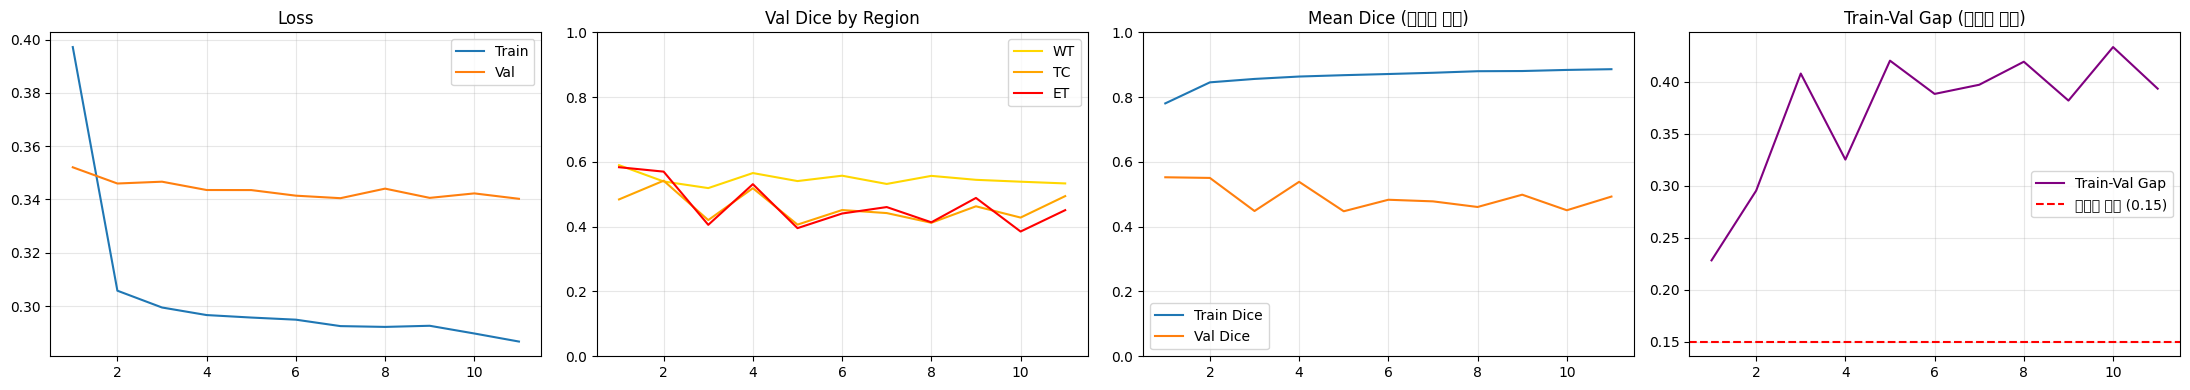

저장: /Users/baiohelseu/brats_work/curves_2d_unet.png


In [13]:
hist = pd.DataFrame(history)

fig, axes = plt.subplots(1, 4, figsize=(22, 4))

# Loss
axes[0].plot(hist['epoch'], hist['train_loss'], label='Train')
axes[0].plot(hist['epoch'], hist['val_loss'],   label='Val')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

# Val Dice by region
axes[1].plot(hist['epoch'], hist['val_WT'], label='WT', color='gold')
axes[1].plot(hist['epoch'], hist['val_TC'], label='TC', color='orange')
axes[1].plot(hist['epoch'], hist['val_ET'], label='ET', color='red')
axes[1].set_title('Val Dice by Region')
axes[1].set_ylim(0, 1); axes[1].legend(); axes[1].grid(alpha=0.3)

# Mean Dice — 과적합 확인
axes[2].plot(hist['epoch'], hist['train_dice'], label='Train Dice')
axes[2].plot(hist['epoch'], hist['val_mean'],   label='Val Dice')
axes[2].set_title('Mean Dice (과적합 확인)')
axes[2].set_ylim(0, 1); axes[2].legend(); axes[2].grid(alpha=0.3)

# Train-Val Gap
axes[3].plot(hist['epoch'], hist['gap'], color='purple', label='Train-Val Gap')
axes[3].axhline(y=0.15, color='red', linestyle='--', label='과적합 경계 (0.15)')
axes[3].set_title('Train-Val Gap (과적합 지표)')
axes[3].legend(); axes[3].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(WORK_DIR / 'curves_2d_unet.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'저장: {WORK_DIR}/curves_2d_unet.png')

## 11. Test 평가 (Dice + Sensitivity + Precision)

In [14]:
model.load_state_dict(torch.load(CKPT_DIR / 'best.pth', map_location=DEVICE))
model.eval()

dice_all, sp_all = [], []

with torch.no_grad():
    for imgs, masks in tqdm(test_loader, desc='Test'):
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        logits      = model(imgs)
        lg_cpu      = logits.cpu().float()
        mk_cpu      = masks.cpu().float()
        dice_all.append(dice_scores(lg_cpu, mk_cpu))
        sp_all.append(sensitivity_precision(lg_cpu, mk_cpu))

dice_res = {k: np.mean([s[k] for s in dice_all]) for k in dice_all[0]}
sp_res   = {k: np.mean([s[k] for s in sp_all])   for k in sp_all[0]}

print('='*55)
print('  2D U-Net — Test Results')
print('='*55)
print(f'  {"":6} {"Dice":>8} {"Sens":>8} {"Prec":>8}')
print('-'*55)
for name in ['WT', 'TC', 'ET']:
    print(f'  {name:6} '
          f'{dice_res[name]:8.4f} '
          f'{sp_res[name+"_sens"]:8.4f} '
          f'{sp_res[name+"_prec"]:8.4f}')
print('-'*55)
print(f'  {"Mean":6} {dice_res["mean"]:8.4f}')
print('='*55)

# CSV 저장
row  = {
    'model': '2D_UNet',
    'Dice_WT': round(dice_res['WT'],   4),
    'Dice_TC': round(dice_res['TC'],   4),
    'Dice_ET': round(dice_res['ET'],   4),
    'Dice_mean': round(dice_res['mean'], 4),
    'Sens_WT': round(sp_res['WT_sens'], 4),
    'Sens_TC': round(sp_res['TC_sens'], 4),
    'Sens_ET': round(sp_res['ET_sens'], 4),
    'Prec_WT': round(sp_res['WT_prec'], 4),
    'Prec_TC': round(sp_res['TC_prec'], 4),
    'Prec_ET': round(sp_res['ET_prec'], 4),
}
path = WORK_DIR / 'metrics_all_models.csv'
df   = pd.read_csv(path) if path.exists() else pd.DataFrame()
pd.concat([df, pd.DataFrame([row])], ignore_index=True).to_csv(path, index=False)
hist.to_csv(WORK_DIR / 'history_2d_unet.csv', index=False)
print(f'\n✓ 저장 완료: {WORK_DIR}')

Test: 100%|██████████| 569/569 [01:15<00:00,  7.52it/s]

  2D U-Net — Test Results
             Dice     Sens     Prec
-------------------------------------------------------
  WT       0.5543   0.8326   0.5803
  TC       0.4708   0.9015   0.4783
  ET       0.5673   0.9139   0.5761
-------------------------------------------------------
  Mean     0.5308

✓ 저장 완료: /Users/baiohelseu/brats_work


## 12. 예측 시각화

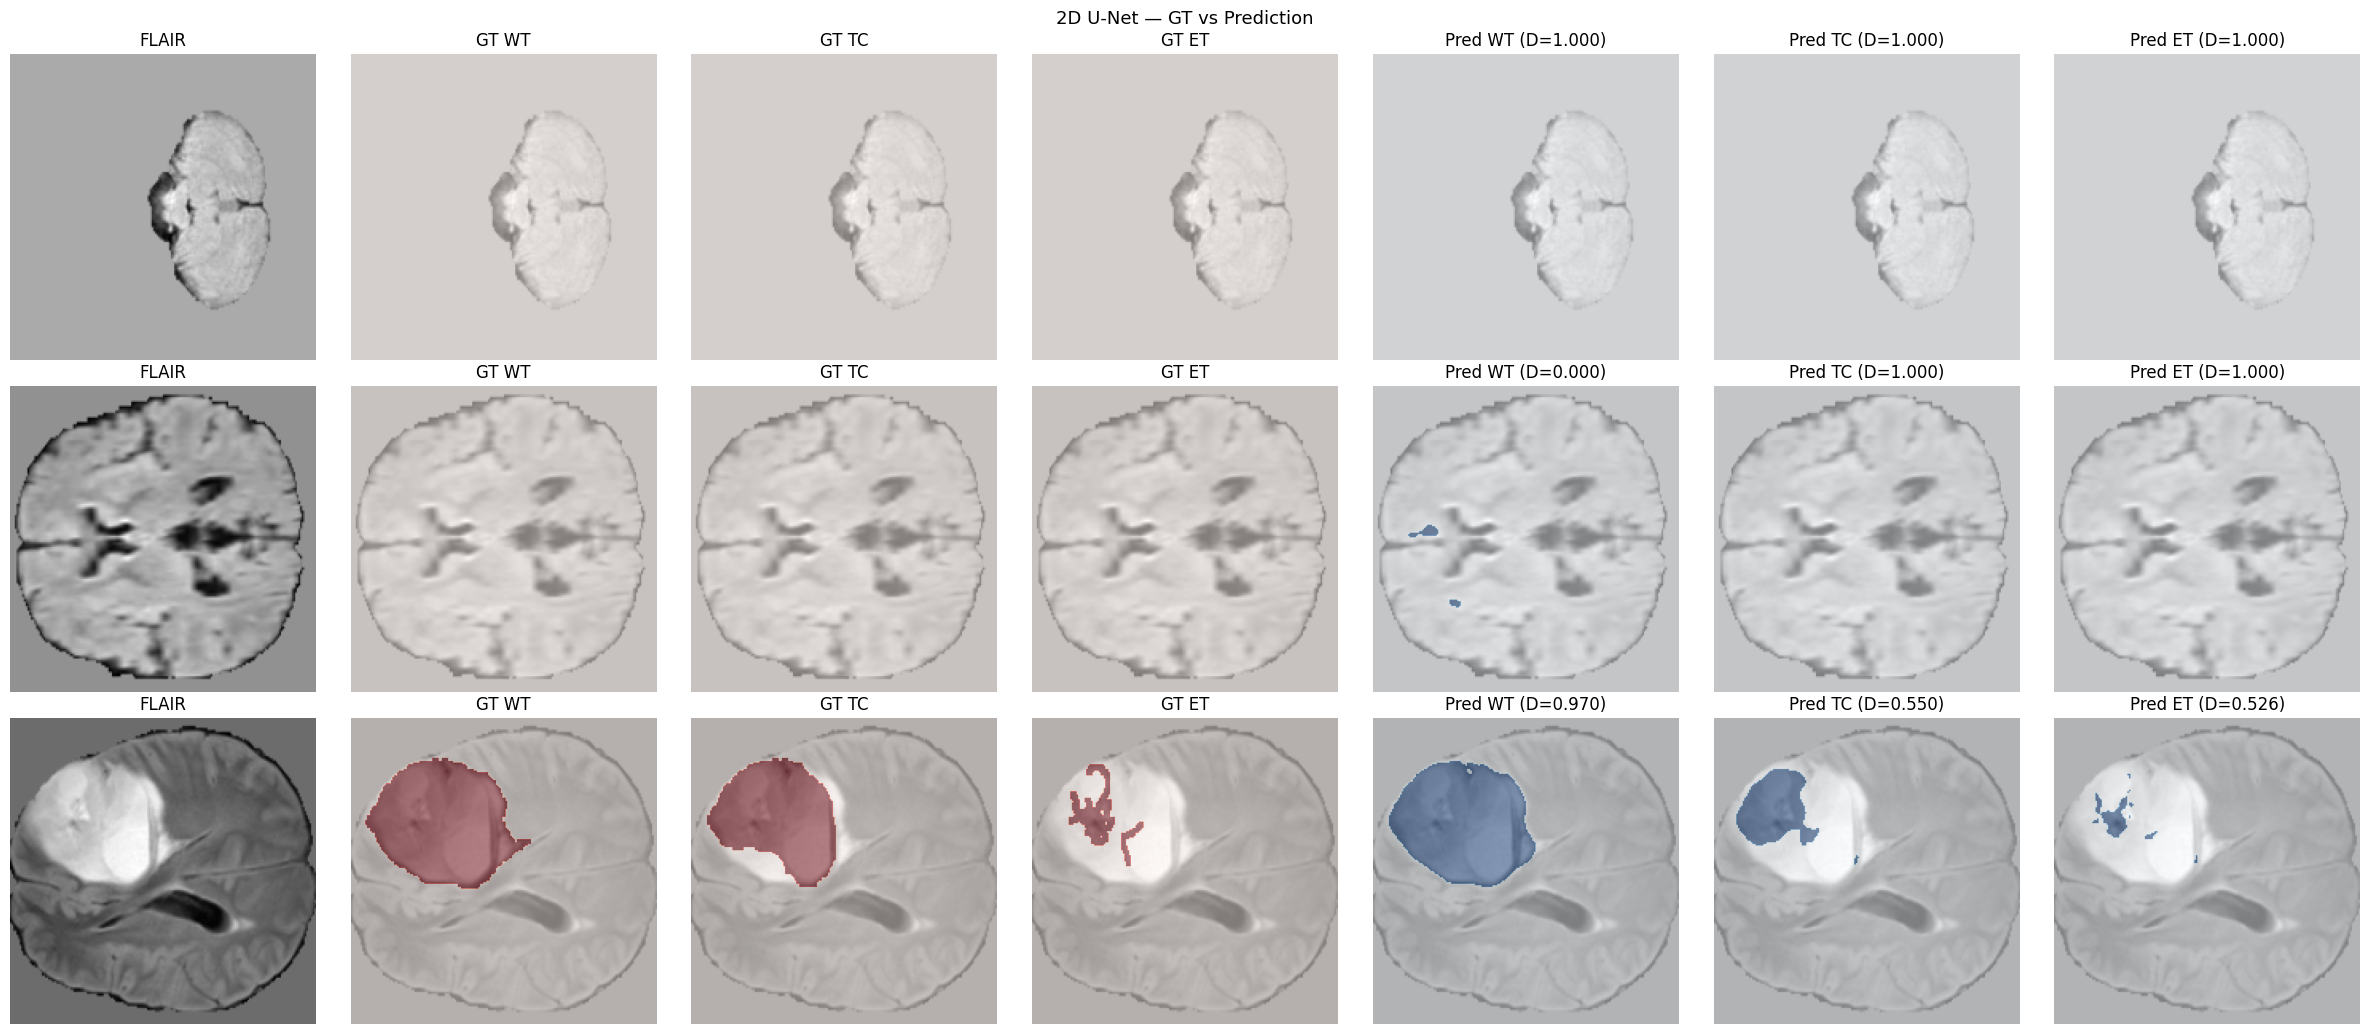

In [15]:
def visualize_predictions(model, dataset, device, n: int = 3, thr: float = 0.5):
    model.eval()
    indices = random.sample(range(len(dataset)), n)
    fig, axes = plt.subplots(n, 7, figsize=(24, 3.5*n))
    if n == 1:
        axes = axes[np.newaxis, :]

    region_names = ['WT', 'TC', 'ET']

    with torch.no_grad():
        for row, idx in enumerate(indices):
            img, mask = dataset[idx]
            logit     = model(img.unsqueeze(0).to(device))
            pred      = (torch.sigmoid(logit.cpu().float()) > thr).squeeze(0)  # (3, H, W)

            flair = img[0].numpy()   # FLAIR channel

            axes[row, 0].imshow(flair, cmap='gray')
            axes[row, 0].set_title('FLAIR')
            axes[row, 0].axis('off')

            for c, name in enumerate(region_names):
                # GT
                axes[row, 1+c].imshow(flair, cmap='gray')
                axes[row, 1+c].imshow(mask[c].numpy(), alpha=0.5, cmap='Reds', vmin=0, vmax=1)
                axes[row, 1+c].set_title(f'GT {name}')
                axes[row, 1+c].axis('off')
                # Pred
                d = dice_scores(logit.cpu().float(), mask.unsqueeze(0))[name]
                axes[row, 4+c].imshow(flair, cmap='gray')
                axes[row, 4+c].imshow(pred[c].numpy(), alpha=0.5, cmap='Blues', vmin=0, vmax=1)
                axes[row, 4+c].set_title(f'Pred {name} (D={d:.3f})')
                axes[row, 4+c].axis('off')

    plt.suptitle('2D U-Net — GT vs Prediction', fontsize=13)
    plt.tight_layout()
    plt.savefig(WORK_DIR / 'viz_2d_unet.png', dpi=120, bbox_inches='tight')
    plt.show()


visualize_predictions(model, test_ds, DEVICE, n=3)